In [93]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

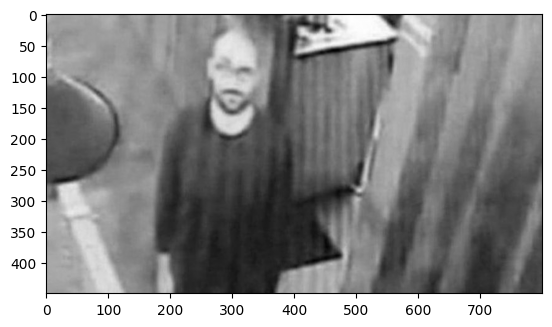

In [94]:
cctv = cv.imread('backup.jpg')
cctvG = cv.cvtColor(cctv, cv.COLOR_BGR2GRAY)

plt.imshow(cctvG, cmap = 'gray')

In [95]:
def filtering(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for val in region.ravel():
                        total += int(val)
                    canvas[i, j] = total // area

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel().tolist()
                    values.sort()
                    n = len(values)
                    mid = n // 2
                    if n % 2 == 1:
                        median_val = values[mid]
                    else:
                        median_val = (values[mid - 1] + values[mid]) // 2
                    canvas[i, j] = median_val

        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val
        case 'sharp':
            kernel = np.array([[1/9, 1/9, 1/9],
                            [1/9, 1/5, 1/9],
                            [1/9, 1/9, 1/9]])
            pad = 1
            padded = np.pad(img, pad, mode='edge')
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+3, j:j+3]
                    val = np.sum(region.astype(np.uint8) * kernel)
                    canvas[i, j] = np.clip(val, 0, 255)

        case 'smooth':
            kernel = np.array([[1/10, 1/10, 1/10],
                            [1/10, 1/5, 1/10],
                            [1/10, 1/10, 1/10]])
            pad = 1
            padded = np.pad(img, pad, mode='edge')
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+3, j:j+3]
                    val = np.sum(region.astype(np.uint8) * kernel) // 16
                    canvas[i, j] = np.clip(val, 0, 255)
    
    return canvas

Text(0.5, 1.0, 'Smoothing + Sharpening')

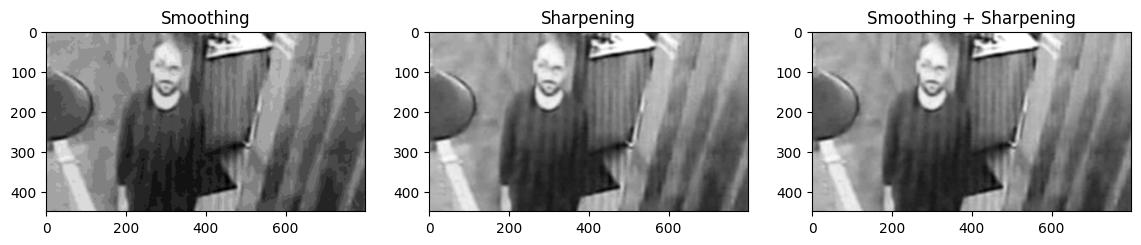

In [96]:
cctvSmooth = filtering(cctvG, 3, 'smooth')
cctvSharp = filtering(cctvG, 3, 'sharp')
cctvKomb = filtering(cctvG, 3, 'smooth')
cctvKomb = filtering(cctvG, 3, 'sharp')

plt.figure(figsize=(14, 8))

plt.subplot(1, 3, 1)
plt.imshow(cctvSmooth, cmap = 'gray')
plt.title('Smoothing')

plt.subplot(1, 3, 2)
plt.imshow(cctvSharp, cmap = 'gray')
plt.title('Sharpening')

plt.subplot(1, 3, 3)
plt.imshow(cctvKomb, cmap = 'gray')
plt.title('Smoothing + Sharpening')

In [97]:
 # kernel sobel sumbu x / x-axis sobel kernel
sobelX = np.array([
 [-1, 0, 1],
 [-2, 0, 2],
 [-1, 0, 1]
], dtype=np.float32)
 # kernel sobel sumbu y / y-axis sobel kernel
sobelY = np.array([
 [1, 2, 1],
 [0, 0, 0],
 [-1, -2, -1]
], dtype=np.float32)

# kernel prewitt sumbu x / x-axis prewitt kernel
prewittX = np.array([
[-1, 0, 1],
[-1, 0, 1],
[-1, 0, 1]
], dtype=np.float32)
# kernel prewitt sumbu y / y-axis prewitt kernel
prewittY = np.array([
[1, 1, 1],
[0, 0, 0],
[-1, -1, -1]
], dtype=np.float32)

# kernel roberts sumbu x / x-axis sobel kernel
robertsX = np.array([
[1, 0],
[0, -1]
], dtype=np.float32)
# kernel roberts sumbu y / y-axis sobel kernel
robertsY = np.array([
[0, 1],
[-1, 0]
], dtype=np.float32)

def convolution(img, kernelX, kernelY=None):
    size = kernelX.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernelX)
    
    if kernelY is not None:
        canvasY = np.zeros_like(img).astype(np.float32)
        padded = np.pad(img, pad_size, mode='constant')
        for i in range(height):
            for j in range(width):
                region = padded[i:i+size, j:j+size]
                canvasY[i, j] = np.sum(region * kernelY)
        canvas = np.sqrt(canvas**2 + canvasY**2)
    
    canvas = canvas / canvas.max() * 255
    return np.clip(canvas, 0, 255).astype(np.uint8)

Text(0.5, 1.0, 'Prewitt + Sobel + Roberts')

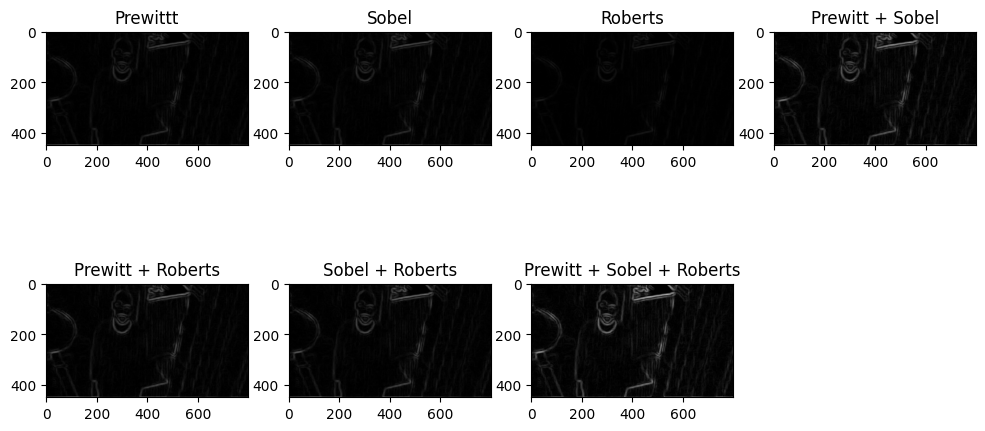

In [98]:
prewitt = convolution(cctvKomb, prewittX, prewittY)
sobel = convolution(cctvKomb, sobelX, sobelY)
roberts = convolution(cctvKomb, robertsX, robertsY)
preSob = prewitt + sobel
preRob = prewitt + roberts
sobRob = sobel + roberts 
preSobRob = prewitt + sobel + roberts

plt.figure(figsize=(12, 6))

plt.subplot(2, 4, 1)
plt.imshow(prewitt, cmap = 'gray')
plt.title('Prewittt')

plt.subplot(2, 4, 2)
plt.imshow(sobel, cmap = 'gray')
plt.title('Sobel')

plt.subplot(2, 4, 3)
plt.imshow(roberts, cmap = 'gray')
plt.title('Roberts')

plt.subplot(2, 4, 4)
plt.imshow(preSob, cmap = 'gray')
plt.title('Prewitt + Sobel')

plt.subplot(2, 4, 5)
plt.imshow(preRob, cmap = 'gray')
plt.title('Prewitt + Roberts')

plt.subplot(2, 4, 6)
plt.imshow(sobRob, cmap = 'gray')
plt.title('Sobel + Roberts')

plt.subplot(2, 4, 7)
plt.imshow(preSobRob, cmap = 'gray')
plt.title('Prewitt + Sobel + Roberts')

In [99]:
def thresholding (image, threshold):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype = image.dtype)
    for i in range(h):
        for j in range(w):
            if image[i, j] > threshold:
                hasil[i, j] = 255
            else:
                hasil[i, j] = 0

    return hasil

Text(0.5, 1.0, 'Threshold 60')

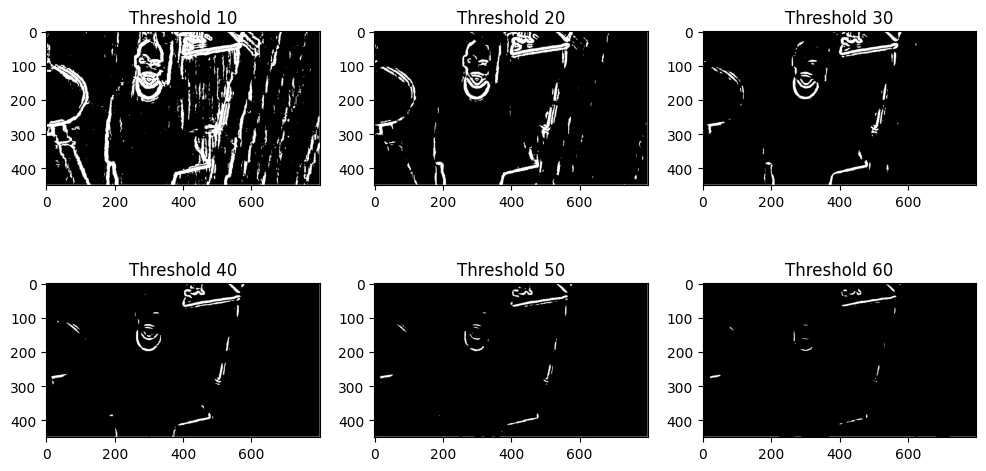

In [100]:
cctvT10 = thresholding(sobRob, 10)
cctvT20 = thresholding(sobRob, 20)
cctvT30 = thresholding(sobRob, 30)
cctvT40 = thresholding(sobRob, 40)
cctvT50 = thresholding(sobRob, 50)
cctvT60 = thresholding(sobRob, 60)

plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
plt.imshow(cctvT10, cmap = 'gray')
plt.title('Threshold 10')

plt.subplot(2, 3, 2)
plt.imshow(cctvT20, cmap = 'gray')
plt.title('Threshold 20')

plt.subplot(2, 3, 3)
plt.imshow(cctvT30, cmap = 'gray')
plt.title('Threshold 30')

plt.subplot(2, 3, 4)
plt.imshow(cctvT40, cmap = 'gray')
plt.title('Threshold 40')

plt.subplot(2, 3, 5)
plt.imshow(cctvT50, cmap = 'gray')
plt.title('Threshold 50')

plt.subplot(2, 3, 6)
plt.imshow(cctvT60, cmap = 'gray')
plt.title('Threshold 60')

In [ ]:
def filter(img, size, mode):
    # cek grayscale atau rgb
    if img.ndim == 3:
        hasil = np.zeros_like(img, dtype=np.uint8)
        for c in range(3):
            hasil[:, :, c] = filter(img[:, :, c], size, mode)
        return hasil

    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    canvas[i, j] = np.sum(region) // area

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    sorted_vals = sorted(values)
                    canvas[i, j] = sorted_vals[len(sorted_vals) // 2]

        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val

    return canvas


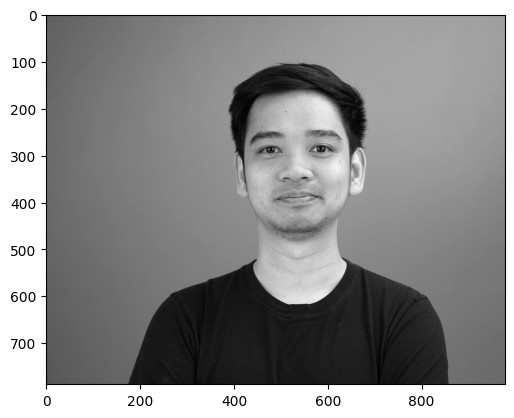

In [159]:
david = cv.imread('david.jpg')
davidG = cv.cvtColor(david, cv.COLOR_BGR2GRAY)

plt.imshow(davidG, cmap = 'gray')

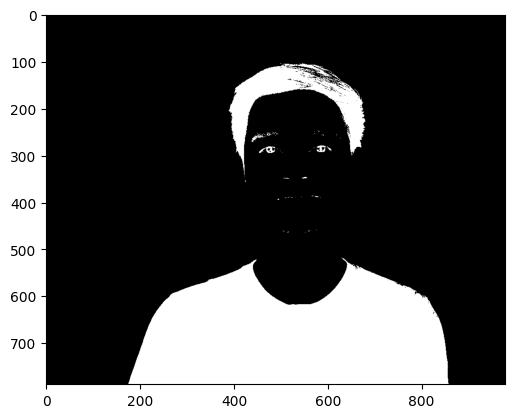

In [162]:
def thresholdingg (image, threshold):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype = image.dtype)
    for i in range(h):
        for j in range(w):
            if image[i, j] < threshold:
                hasil[i, j] = 255
            else:
                hasil[i, j] = 0

    return hasil
davidT = thresholdingg(davidG, 50)

plt.imshow(davidT, cmap = 'gray')

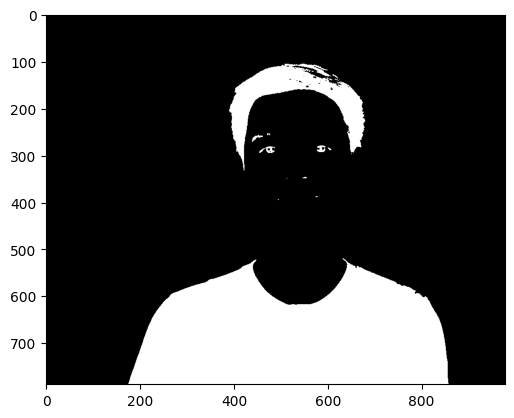

In [164]:
davidM = filtering(davidT, 3, 'median')

plt.imshow(davidM, cmap = 'gray')